In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from pathlib import Path

plt.style.use("default")
sns.set_theme(style="whitegrid")

BASE_DIR = Path.cwd().parent.parent

print("Project Root:", BASE_DIR)

fund_master = pd.read_csv(
    BASE_DIR / "data" / "raw" / "01_fund_master.csv"
)

transactions = pd.read_csv(
    BASE_DIR / "data" / "processed" / "clean_transactions.csv"
)

performance = pd.read_csv(
    BASE_DIR / "data" / "raw" / "07_scheme_performance.csv"
)

nav_history = pd.read_csv(
    BASE_DIR / "data" / "processed" / "clean_nav_history_filled.csv"
)

print("Fund Master:", fund_master.shape)
print("Transactions:", transactions.shape)
print("Performance:", performance.shape)
print("NAV History:", nav_history.shape)

Project Root: C:\Users\sujal\PycharmProjects\bluestock_mf_capstone
Fund Master: (40, 15)
Transactions: (32778, 13)
Performance: (40, 19)
NAV History: (64320, 3)


In [5]:
datasets = {
    "Fund Master": fund_master,
    "Transactions": transactions,
    "Performance": performance,
    "NAV History": nav_history
}

for name, df in datasets.items():

    print("\n" + "=" * 60)
    print(name)

    print("Shape:", df.shape)

    display(df.head(3))


Fund Master
Shape: (40, 15)


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03



Transactions
Shape: (32778, 13)


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified



Performance
Shape: (40, 19)


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High



NAV History
Shape: (64320, 3)


,date,amfi_code,nav
0,2022-01-03,100016,520.4608
1,2022-01-04,100016,515.0971
2,2022-01-05,100016,521.7239


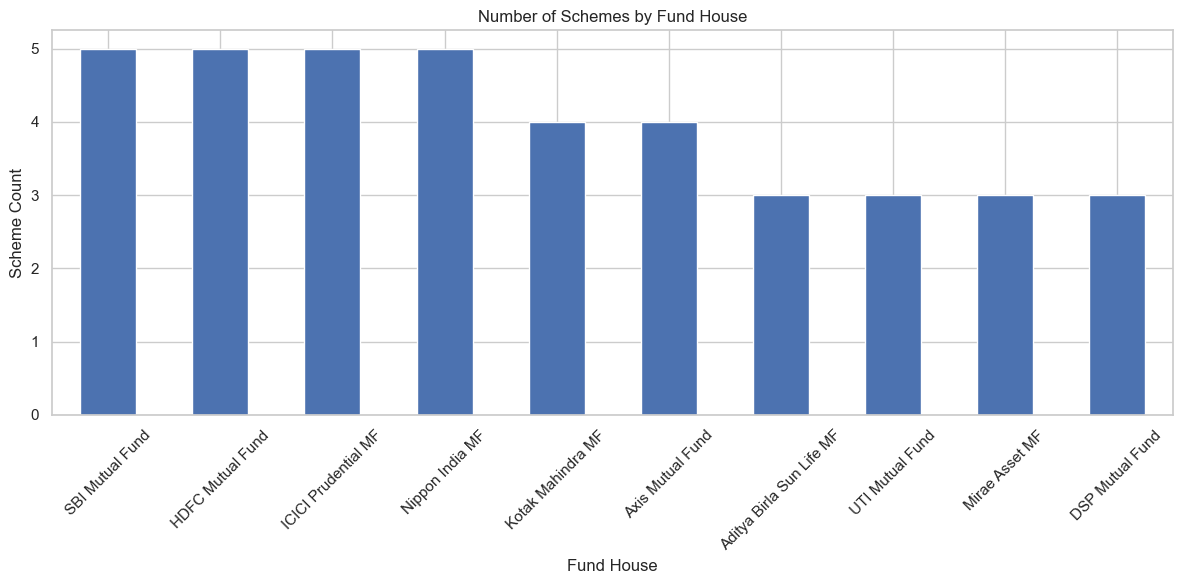

In [6]:
plt.figure(figsize=(12,6))

fund_master["fund_house"] \
    .value_counts() \
    .plot(kind="bar")

plt.title("Number of Schemes by Fund House")
plt.xlabel("Fund House")
plt.ylabel("Scheme Count")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Insight: Fund House Distribution

- The dataset contains 10 Asset Management Companies (AMCs).
- Scheme offerings are distributed across multiple fund houses.
- Larger AMCs generally provide greater product diversification.
- Fund house distribution helps evaluate market concentration and competition.

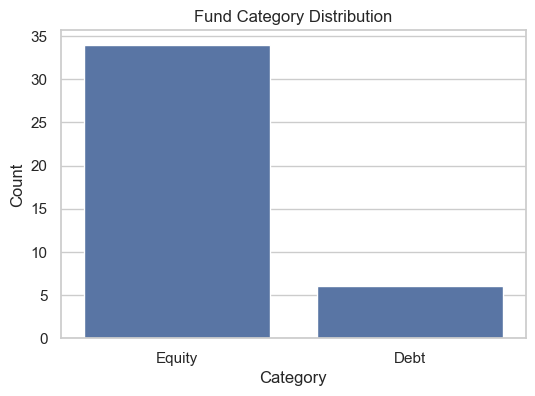

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=fund_master,
    x="category"
)

plt.title("Fund Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

## Insight: Category Distribution

- Equity funds dominate the dataset.
- Debt funds represent a smaller share.
- This indicates a stronger focus on growth-oriented investment products.

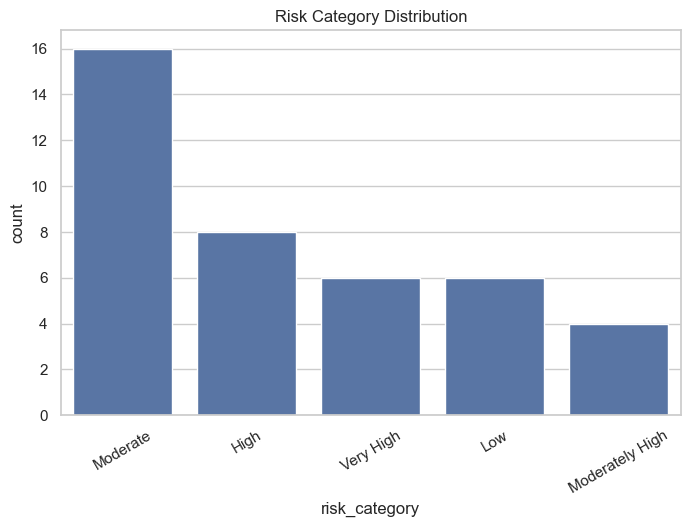

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=fund_master,
    x="risk_category",
    order=fund_master["risk_category"].value_counts().index
)

plt.title("Risk Category Distribution")
plt.xticks(rotation=30)

plt.show()

## Insight: Risk Classification

- Most schemes fall under Moderate to Very High risk categories.
- Higher-risk schemes are common in equity-oriented investments.
- Risk segmentation will be useful for the recommendation engine and dashboard filters.

In [ ]:
plt.figure(figsize=(6,4))

transactions["gender"] \
    .value_counts() \
    .plot(kind="bar")

plt.title("Investor Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

## Insight: Gender Analysis

- This chart shows participation across gender groups.
- Understanding investor demographics helps identify market penetration opportunities.
- Differences in participation may indicate targeting opportunities for AMCs.

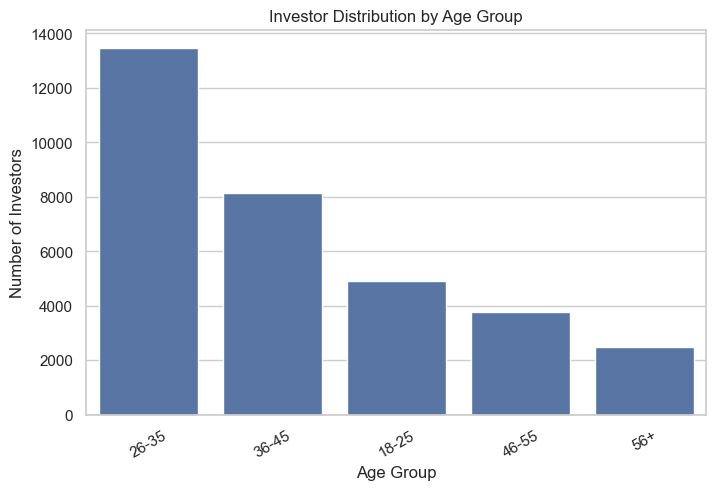

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=transactions,
    x="age_group",
    order=transactions["age_group"].value_counts().index
)

plt.title("Investor Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Investors")

plt.xticks(rotation=30)

plt.show()

## Insight: Age Group Analysis

- This chart identifies the most active investor age segments.
- Understanding age demographics helps tailor investment products and marketing strategies.
- Younger investors often prefer growth-oriented funds, while older investors may prefer stability and income-focused products.

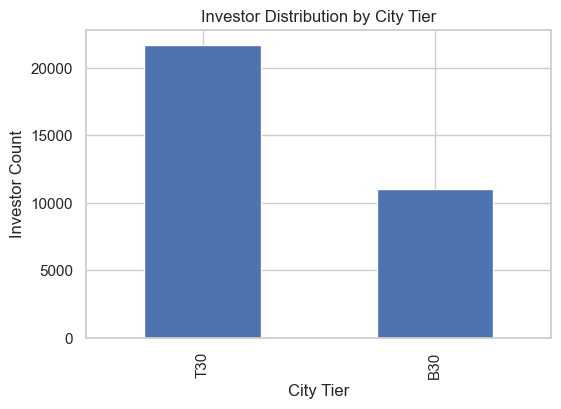

In [10]:
plt.figure(figsize=(6,4))

transactions["city_tier"] \
    .value_counts() \
    .plot(kind="bar")

plt.title("Investor Distribution by City Tier")
plt.xlabel("City Tier")
plt.ylabel("Investor Count")

plt.show()

## Insight: City Tier Analysis

- Investor participation varies across Tier 1, Tier 2, and Tier 3 cities.
- Tier-wise analysis helps assess financial product penetration.
- AMCs can use this information to target under-served regions.

In [ ]:
state_investment = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

state_investment.plot(kind="bar")

plt.title("Top 10 States by Investment Amount")
plt.xlabel("State")
plt.ylabel("Investment Amount (INR)")

plt.tight_layout()

plt.show()

## Insight: State-wise Investment

- Certain states contribute significantly more investment volume than others.
- High-contribution states represent important markets for mutual fund companies.
- Geographic concentration can influence business expansion strategies.

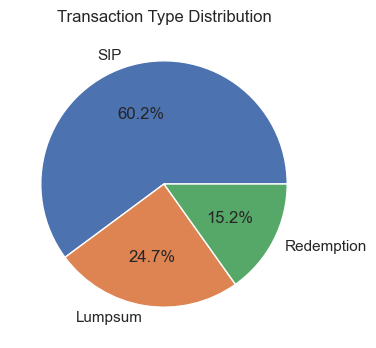

In [12]:
plt.figure(figsize=(6,4))

transactions["transaction_type"] \
    .value_counts() \
    .plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")

plt.title("Transaction Type Distribution")

plt.show()

## Insight: Transaction Behaviour

- SIP transactions dominate investor activity.
- Regular SIP contributions indicate disciplined long-term investing behaviour.
- Redemption patterns can provide insight into investor retention and market sentiment.

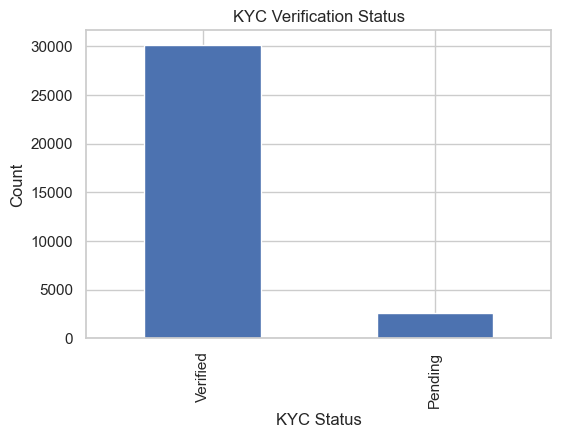

In [11]:
plt.figure(figsize=(6,4))

transactions["kyc_status"] \
    .value_counts() \
    .plot(kind="bar")

plt.title("KYC Verification Status")
plt.xlabel("KYC Status")
plt.ylabel("Count")

plt.show()

## Insight: KYC Compliance

- Most investors have completed KYC verification.
- Pending KYC cases represent onboarding opportunities.
- Strong KYC compliance improves operational efficiency and regulatory adherence.

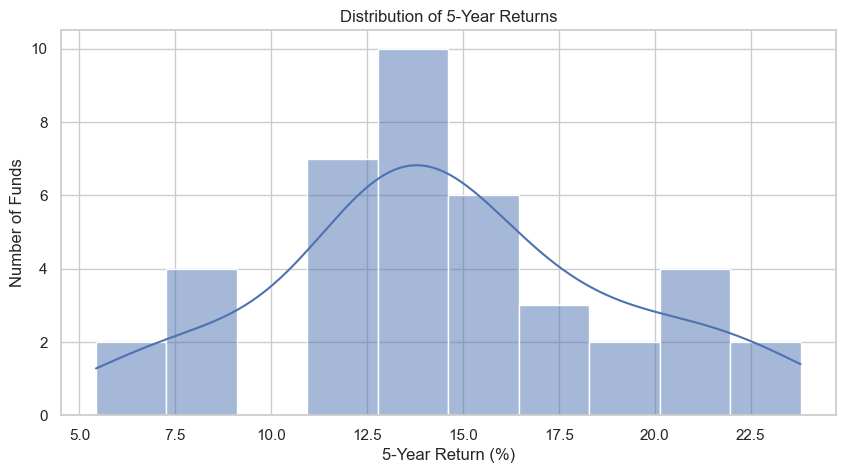

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(
    performance["return_5yr_pct"],
    bins=10,
    kde=True
)

plt.title("Distribution of 5-Year Returns")
plt.xlabel("5-Year Return (%)")
plt.ylabel("Number of Funds")

plt.show()

## Insight: Long-Term Returns

- The distribution highlights variation in long-term fund performance.
- Most funds cluster around a common return range.
- Outliers represent exceptionally strong or weak performers.

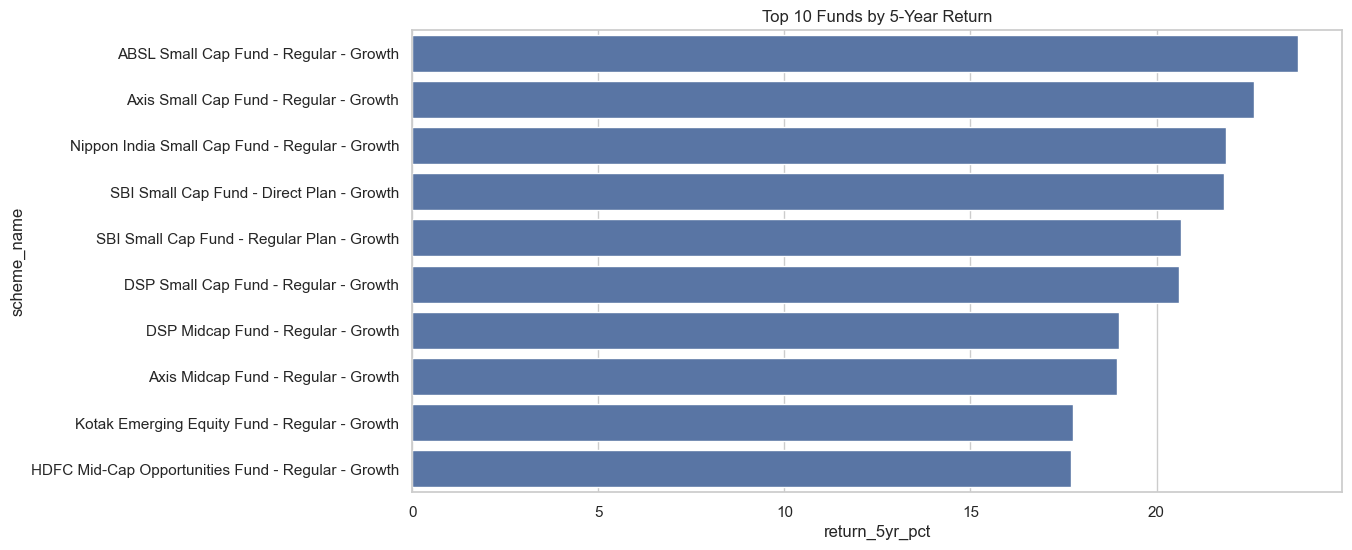

In [15]:
top_funds = (
    performance
    .sort_values(
        "return_5yr_pct",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_funds,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds by 5-Year Return")

plt.show()

## Insight: Top Performing Funds

- These funds generated the strongest long-term returns.
- High performers can be used for benchmarking and portfolio construction.
- Performance should be evaluated alongside risk metrics.

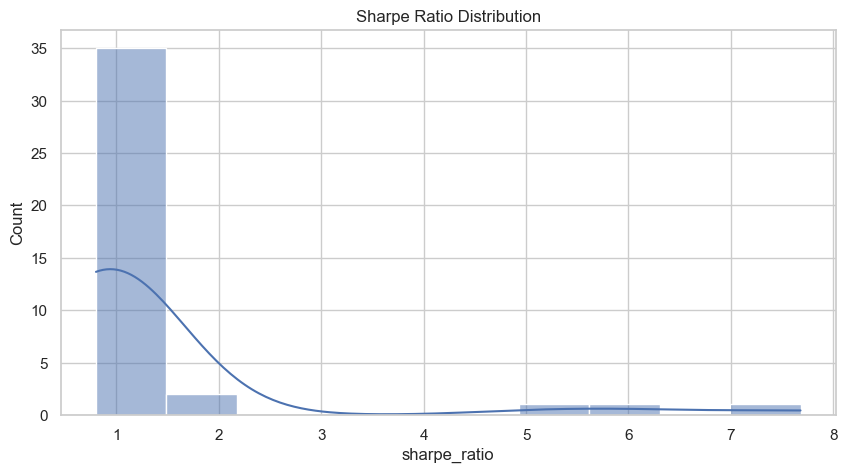

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(
    performance["sharpe_ratio"],
    bins=10,
    kde=True
)

plt.title("Sharpe Ratio Distribution")

plt.show()

## Insight: Risk-Adjusted Performance

- Sharpe Ratio measures return per unit of risk.
- Higher values indicate superior risk-adjusted performance.
- Funds with strong returns but poor Sharpe Ratios may involve excessive volatility.

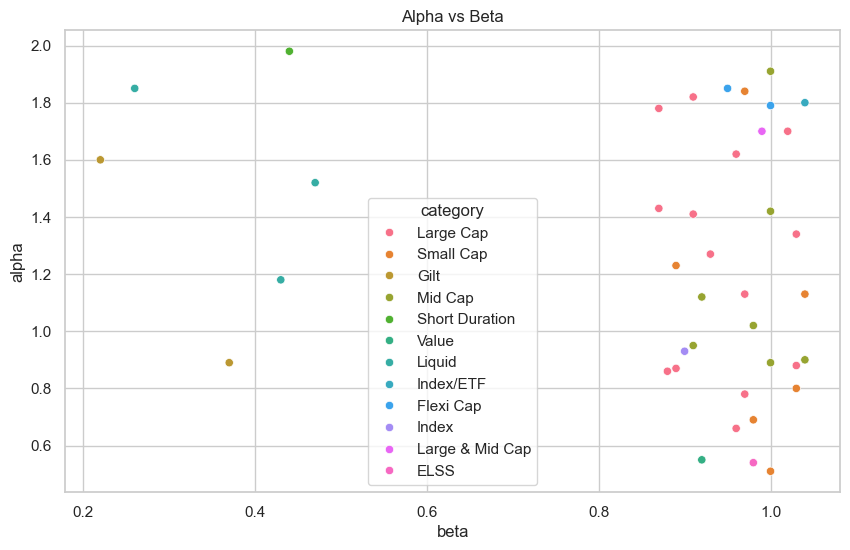

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=performance,
    x="beta",
    y="alpha",
    hue="category"
)

plt.title("Alpha vs Beta")

plt.show()

## Insight: Alpha and Beta Relationship

- Alpha measures excess return relative to benchmark performance.
- Beta measures market sensitivity.
- Funds with positive Alpha and moderate Beta often represent attractive opportunities.

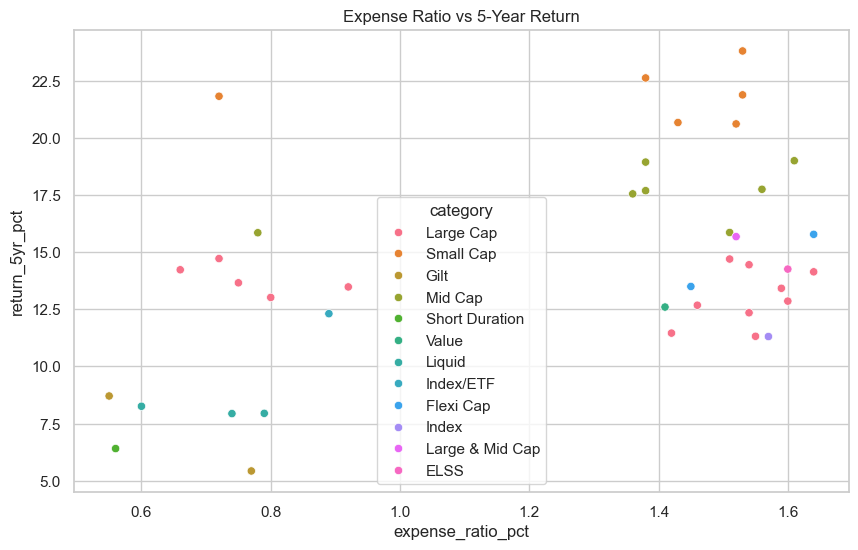

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=performance,
    x="expense_ratio_pct",
    y="return_5yr_pct",
    hue="category"
)

plt.title("Expense Ratio vs 5-Year Return")

plt.show()

## Insight: Cost vs Performance

- Higher expenses do not always translate into higher returns.
- Investors should evaluate whether active management justifies additional costs.
- Cost efficiency remains a critical factor in long-term investing.

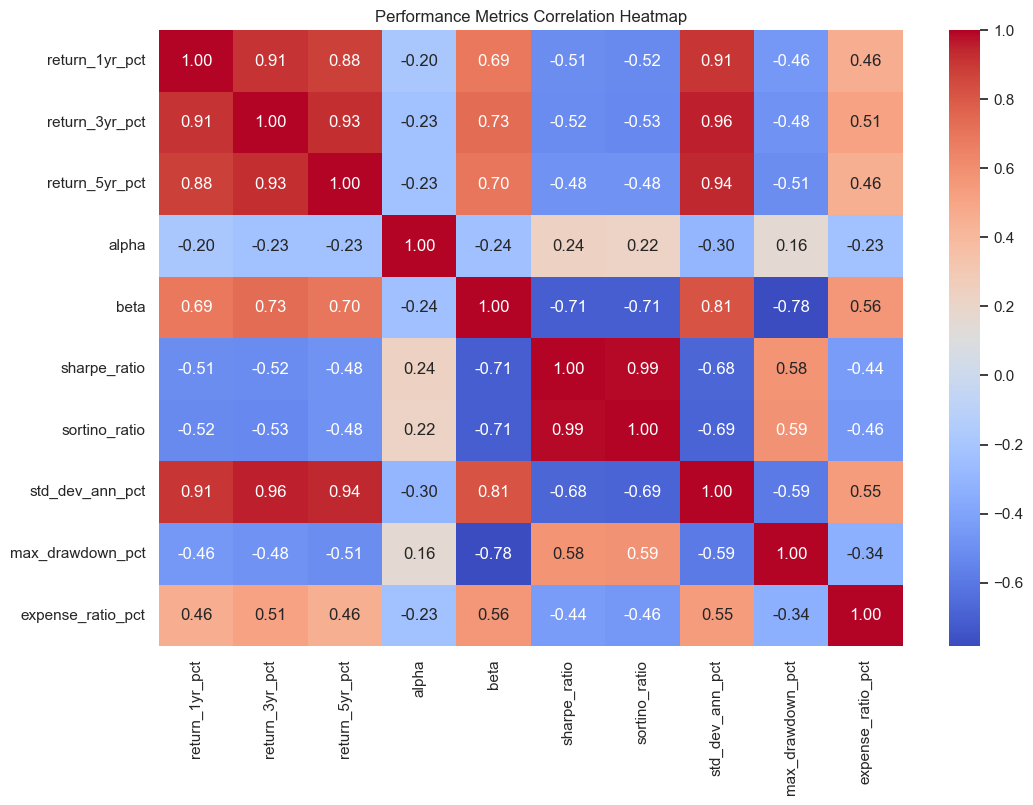

In [19]:
numeric_cols = [
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct",
    "alpha",
    "beta",
    "sharpe_ratio",
    "sortino_ratio",
    "std_dev_ann_pct",
    "max_drawdown_pct",
    "expense_ratio_pct"
]

corr = performance[numeric_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Performance Metrics Correlation Heatmap")

plt.show()

## Insight: Correlation Analysis

- Correlation analysis reveals relationships between return, risk, and cost metrics.
- Strong positive correlations indicate metrics moving together.
- Negative correlations can reveal trade-offs between risk and performance.

# Executive Summary

## Key Findings

### Fund Landscape

* The dataset contains 10 major Asset Management Companies (AMCs).
* Equity funds dominate the investment universe, indicating a stronger focus on long-term wealth creation.
* Most schemes fall within Moderate to Very High risk categories.

### Investor Behaviour

* SIP transactions account for the majority of investment activity, demonstrating disciplined investment behavior.
* Investor participation varies significantly across states and city tiers.
* Most investors have completed KYC verification, indicating strong compliance levels.

### Fund Performance

* Long-term returns vary substantially across schemes.
* Several funds consistently outperform peers over the 5-year horizon.
* Higher expense ratios do not necessarily lead to superior returns.

### Risk Analysis

* Sharpe Ratio analysis highlights meaningful differences in risk-adjusted performance.
* Alpha and Beta metrics reveal varying levels of benchmark outperformance and market sensitivity.
* Correlation analysis identifies relationships between returns, volatility, and risk measures.

## Business Recommendations

1. Promote SIP-based investment products due to strong investor adoption.
2. Expand distribution efforts in underrepresented states and city tiers.
3. Highlight risk-adjusted metrics such as Sharpe Ratio during fund selection.
4. Focus investor education on cost-efficient investment strategies.
5. Use risk profiling and recommendation engines to improve investor-fund matching.

## Conclusion

The exploratory analysis reveals meaningful insights into mutual fund performance, investor behavior, geographic participation, and risk characteristics. These findings establish a strong foundation for advanced performance analytics, risk modeling, portfolio optimization, and dashboard development.


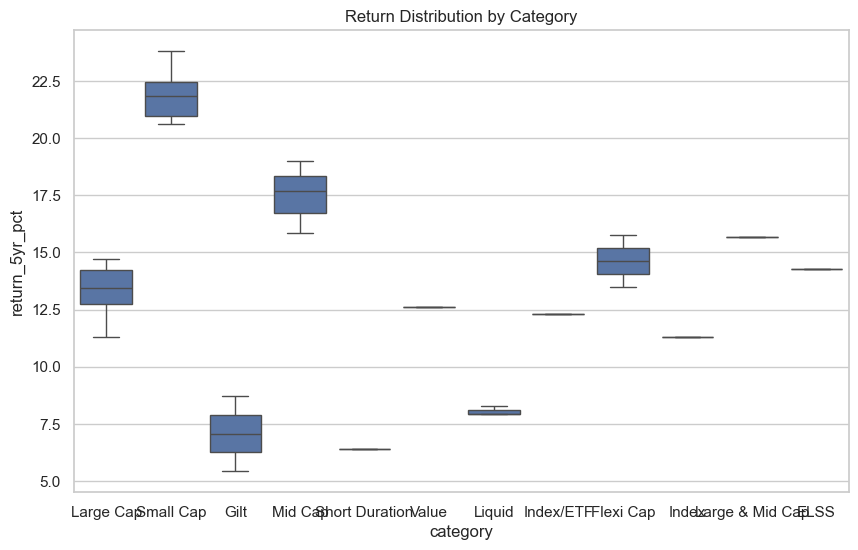

In [20]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=performance,
    x="category",
    y="return_5yr_pct"
)

plt.title("Return Distribution by Category")

plt.show()

## Insight: Category-wise Return Analysis

- Return distributions differ across fund categories.
- Variability indicates differences in risk-return characteristics.
- Category-level comparisons support investment decision-making and benchmarking.

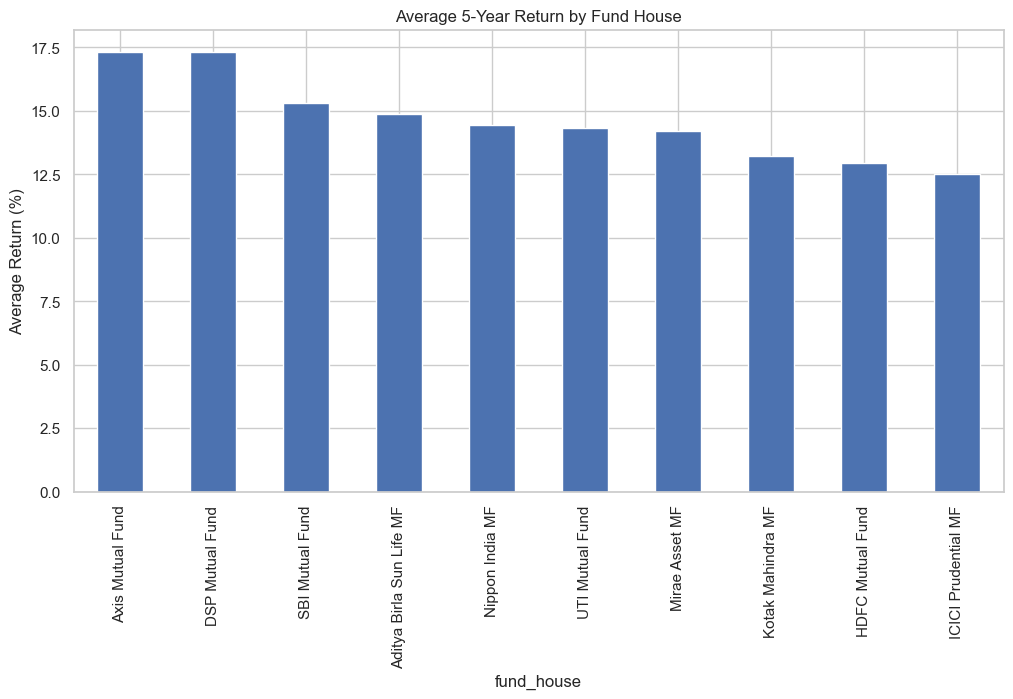

In [22]:
fund_house_returns = (
    performance.groupby("fund_house")["return_5yr_pct"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
fund_house_returns.plot(kind="bar")

plt.title("Average 5-Year Return by Fund House")
plt.ylabel("Average Return (%)")

plt.show()

## Insight: Fund House Performance

- Fund houses demonstrate varying long-term performance characteristics.
- Certain AMCs consistently outperform peers based on average 5-year returns.
- This information can assist investors in AMC selection.

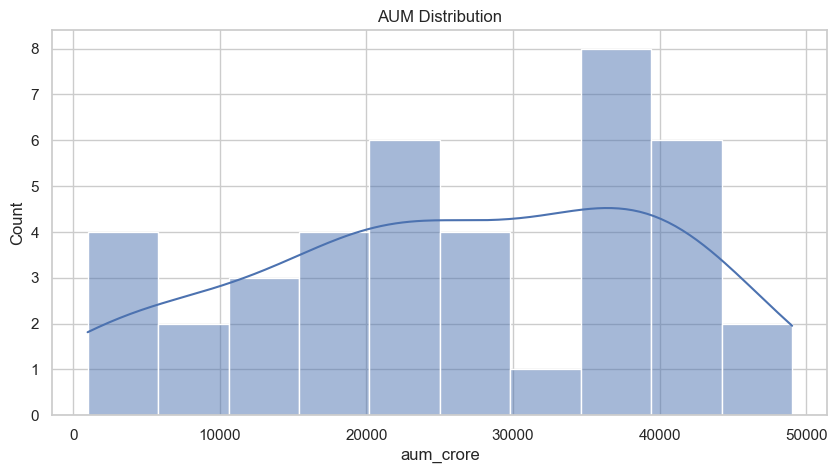

In [24]:
plt.figure(figsize=(10,5))

sns.histplot(
    performance["aum_crore"],
    bins=10,
    kde=True
)

plt.title("AUM Distribution")

plt.show()

## Insight: Assets Under Management

- Fund sizes vary significantly across schemes.
- Larger AUM often indicates investor confidence and operational stability.
- Smaller funds may offer flexibility but can carry additional risk.

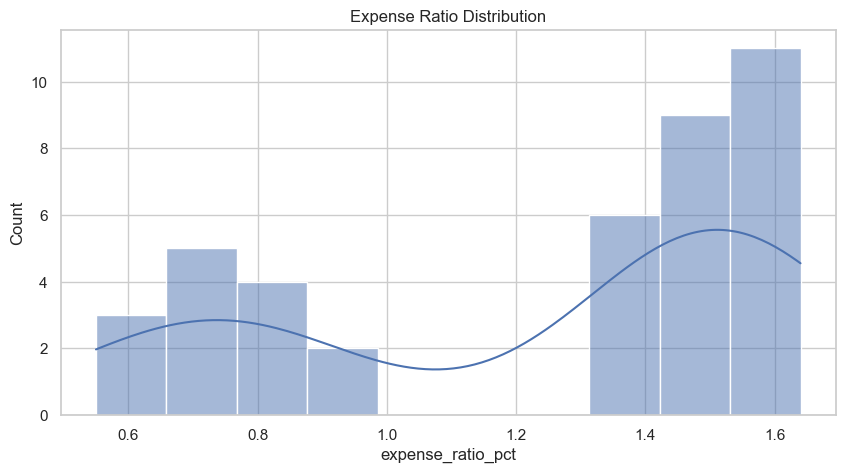

In [25]:
plt.figure(figsize=(10,5))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=10,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.show()

## Insight: Expense Analysis

- Expense ratios differ across schemes.
- Lower costs can significantly improve long-term investor returns.
- Cost efficiency should be evaluated alongside performance metrics.

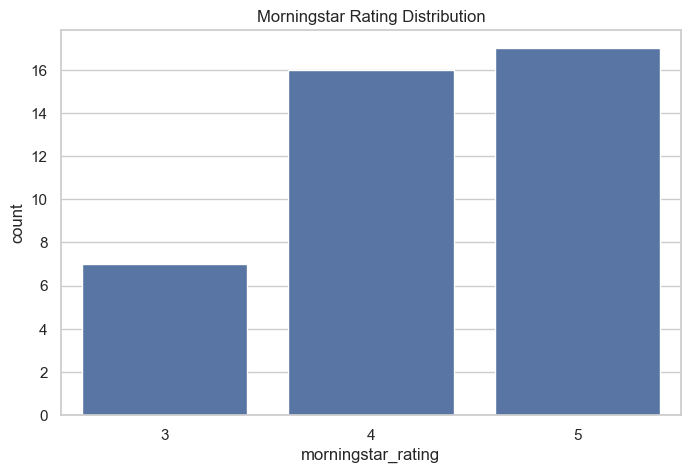

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=performance,
    x="morningstar_rating"
)

plt.title("Morningstar Rating Distribution")

plt.show()

## Insight: Fund Ratings

- Morningstar ratings provide a quick measure of historical performance quality.
- Higher-rated funds generally exhibit stronger risk-adjusted performance.
- Ratings can serve as an initial screening criterion for investors.

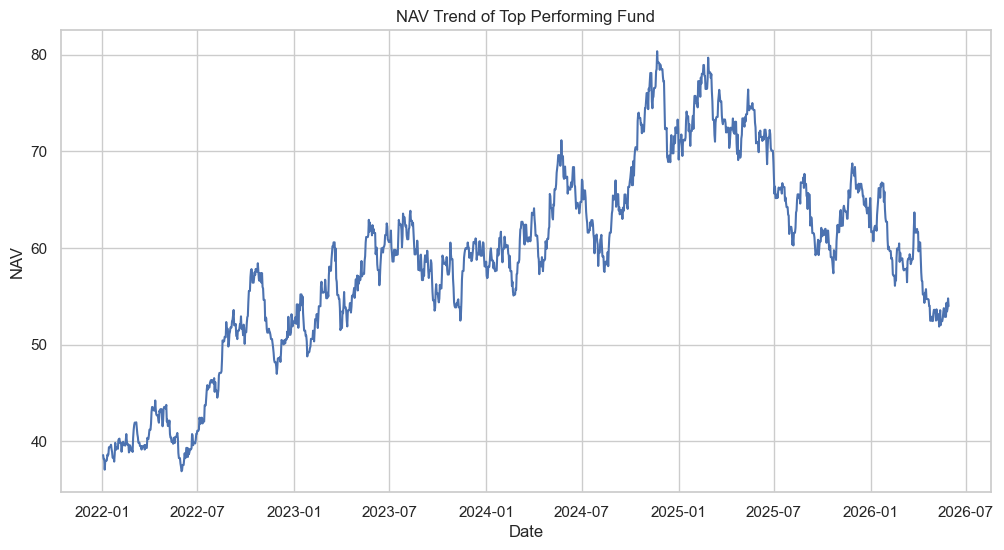

In [29]:
top_code = (
    performance
    .sort_values("return_5yr_pct", ascending=False)
    ["amfi_code"]
    .iloc[0]
)

top_nav = nav_history[
    nav_history["amfi_code"] == top_code
].copy()

top_nav["date"] = pd.to_datetime(top_nav["date"])

plt.figure(figsize=(12,6))

plt.plot(
    top_nav["date"],
    top_nav["nav"]
)

plt.title("NAV Trend of Top Performing Fund")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.show()